# BBC News Classification 
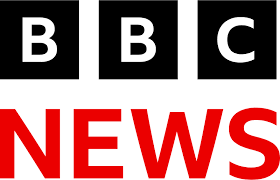

# Introduction 

- This report presents the findings of a BBC News article classification project conducted as part of an AI/ML internship assignment. 

- The project investigates the impact of text summarization on the performance of a Word2Vec-based multi-class text classifier across five news categories: business, entertainment, politics, sport, and tech.

- The BBC News dataset is extracted from kaggle “bbc-text.csv”


In [22]:
# importing librariries

import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns


In [23]:
#Load the dataset

df = pd.read_csv('bbc-text.csv')


In [24]:
#First 5 rows of the dataset
df.head()

,category,text
0,tech,tv future in the hands of viewers with home th...
1,business,worldcom boss left books alone former worldc...
2,sport,tigers wary of farrell gamble leicester say ...
3,sport,yeading face newcastle in fa cup premiership s...
4,entertainment,ocean s twelve raids box office ocean s twelve...


# 1. Dataset overview and Cleaning

### 1.1 Basic inofrmation about the dataset

In [25]:
#Data shape, columns, data types, summary statistics,
#Categories, missing values and duplicates

print('Shape of the dataset:', df.shape, ', rows = ', df.shape[0], ', columns =', df.shape[1])
print('\nColumns in the dataset:', df.columns)
print('\nData types of the columns:\n', df.dtypes)
print('\nSummary statistics of the dataset:\n', df.describe())
print('\nUnique cateogries in the dataset:\n', df['category'].unique())
print('\nNumber of missing values in each column:\n', df.isnull().sum())
print('\nNumber of duplicate rows in the dataset:', df.duplicated().sum())


Shape of the dataset: (2225, 2) , rows =  2225 , columns = 2

Columns in the dataset: Index(['category', 'text'], dtype='str')

Data types of the columns:
 category    str
text        str
dtype: object

Summary statistics of the dataset:
        category                                               text
count      2225                                               2225
unique        5                                               2126
top       sport  ocean s twelve raids box office ocean s twelve...
freq        511                                                  2

Unique cateogries in the dataset:
 <StringArray>
['tech', 'business', 'sport', 'entertainment', 'politics']
Length: 5, dtype: str

Number of missing values in each column:
 category    0
text        0
dtype: int64

Number of duplicate rows in the dataset: 99


#### 1.1.1 Dropping the duplicated values here;



In [26]:
df.drop_duplicates(inplace=True)


In [27]:
df.shape

(2126, 2)

### 1.2 Category distribution

Article count per category:

category
sport            504
business         503
politics         403
entertainment    369
tech             347
Name: count, dtype: int64


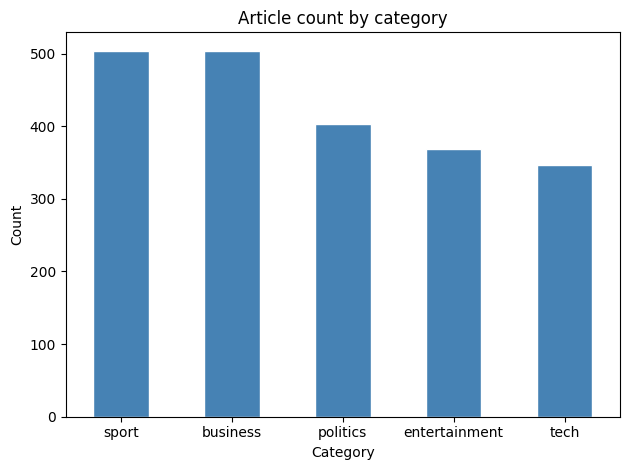

In [28]:
print("Article count per category:\n")
print(df['category'].value_counts())

# Plot
df['category'].value_counts().plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Article count by category')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 1.3 Text sample analysis

Word count stats:

               count   mean    std    min    25%    50%    75%     max
category                                                              
business       503.0  334.0  138.5  142.0  235.5  303.0  395.5   912.0
entertainment  369.0  339.8  274.1  144.0  228.0  267.0  368.0  3570.0
politics       403.0  463.4  308.4   90.0  321.5  451.0  536.0  4492.0
sport          504.0  337.7  192.3  116.0  208.0  297.0  419.8  1671.0
tech           347.0  518.1  251.1  165.0  345.5  462.0  639.5  3007.0


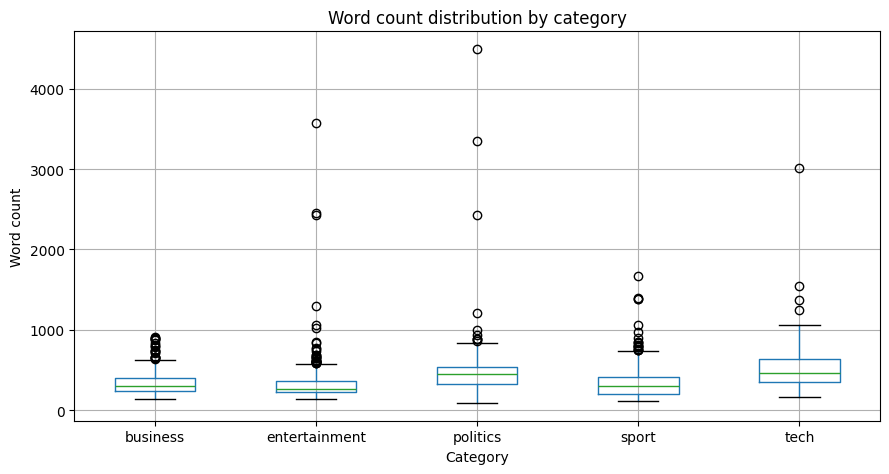

In [29]:
#Adding text word_count and statisticall summarizing

df['word_count'] = df['text'].apply(lambda x: len(x.split()))

print("Word count stats:\n")
print(df.groupby('category')['word_count'].describe().round(1))

# Boxplot per category
df.boxplot(column='word_count', by='category', figsize=(9, 5))
plt.suptitle('')
plt.title('Word count distribution by category')
plt.xlabel('Category')
plt.ylabel('Word count')
plt.tight_layout()
plt.show()

In [30]:
df.head()

,category,text,word_count
0,tech,tv future in the hands of viewers with home th...,737
1,business,worldcom boss left books alone former worldc...,300
2,sport,tigers wary of farrell gamble leicester say ...,246
3,sport,yeading face newcastle in fa cup premiership s...,341
4,entertainment,ocean s twelve raids box office ocean s twelve...,260


### 1.4 (Optional) Sample inspection per category 
- Making sure there are no weird formatting, broken characters and hidden data hiding in the dataset. 

In [31]:
for cat in df['category'].unique():
    sample = df[df['category'] == cat]['text'].values[0]
    print(f"--- {cat.upper()} ---")
    print(sample[:300])
    print()

--- TECH ---
tv future in the hands of viewers with home theatre systems  plasma high-definition tvs  and digital video recorders moving into the living room  the way people watch tv will be radically different in five years  time.  that is according to an expert panel which gathered at the annual consumer elect

--- BUSINESS ---
worldcom boss  left books alone  former worldcom boss bernie ebbers  who is accused of overseeing an $11bn (£5.8bn) fraud  never made accounting decisions  a witness has told jurors.  david myers made the comments under questioning by defence lawyers who have been arguing that mr ebbers was not resp

--- SPORT ---
tigers wary of farrell  gamble  leicester say they will not be rushed into making a bid for andy farrell should the great britain rugby league captain decide to switch codes.   we and anybody else involved in the process are still some way away from going to the next stage   tigers boss john wells t

--- ENTERTAINMENT ---
ocean s twelve raids box off

# 2. Exploratory Data Analysis

### 2.1 Class Distribution 
- looking at how the categories are cdistributed, 
- Are the categories balanced..


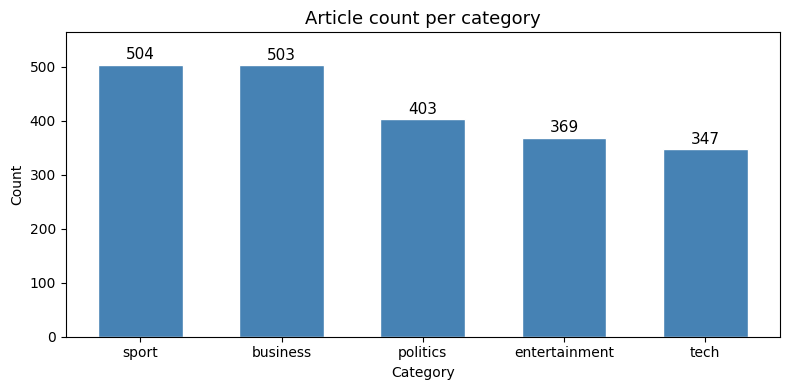


Class distribution:

 category
sport            504
business         503
politics         403
entertainment    369
tech             347
Name: count, dtype: int64

Most common : sport (504)
Least common: tech (347)
Imbalance ratio: 1.45x


In [32]:
# Class distribution

counts = df['category'].value_counts()

fig, ax = plt.subplots(figsize =(8,4))
bars = ax.bar(counts.index, counts.values, color= 'steelblue', edgecolor = 'white', width = 0.6)

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            str(val), ha='center', va='bottom', fontsize=11)

ax.set_title('Article count per category', fontsize=13)
ax.set_xlabel('Category')
ax.set_ylabel('Count')
ax.set_ylim(0, counts.max() + 60)
plt.tight_layout()
plt.show()

print("\nClass distribution:\n\n", counts) 

#seeing how skewes the dataset is among the categories.

print(f"\nMost common : {counts.idxmax()} ({counts.max()})")
print(f"Least common: {counts.idxmin()} ({counts.min()})")
print(f"Imbalance ratio: {counts.max()/counts.min():.2f}x")

### 2.2 Article length analysis
- Using histogram + box plot to vizualize word count statistics per category.
- avg/min/max


 Word count stats per category:

                mean  median  min   max    std
category                                      
business       334.0   303.0  142   912  138.5
entertainment  339.8   267.0  144  3570  274.1
politics       463.4   451.0   90  4492  308.4
sport          337.7   297.0  116  1671  192.3
tech           518.1   462.0  165  3007  251.1


/var/folders/hq/j021gfw15kn44g4836jk8hh80000gn/T/ipykernel_87686/1594088532.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(data_by_Cat, labels=categories)


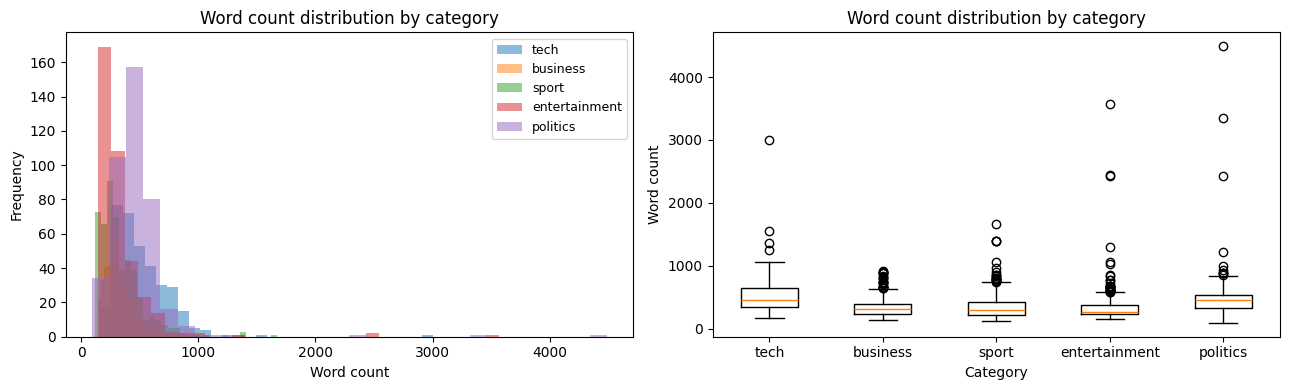

In [33]:
#2.2 Article length analysis 

print('\n Word count stats per category:\n')
print(df.groupby('category')['word_count']
      .agg(['mean','median','min','max', 'std'])
      .round(1))


fig, axes = plt.subplots(1,2, figsize=(13, 4))


#Histogram overlaid per category

for cat in df['category'].unique():
    subset = df[df['category']== cat]['word_count']
    axes[0].hist(subset, bins=30, alpha=0.5, label=cat)

axes[0].set_title('Word count distribution by category')
axes[0].set_xlabel('Word count')
axes[0].set_ylabel('Frequency')
axes[0].legend(fontsize = 9)


#Boxplot per category
categories = df['category'].unique()
data_by_Cat = [df[df['category'] == c]['word_count'] for c in categories]
axes[1].boxplot(data_by_Cat, labels=categories)
axes[1].set_title('Word count distribution by category')
axes[1].set_ylabel('Word count')
axes[1].set_xlabel('Category')

plt.tight_layout()
plt.show()


### 2.3 Most frequent words per category 

- It confirms the categories are meaningfully different 
- Guides preprocessing by helping us clean the unwanted words from top searches per category. 
- Explains if any misundertood results in the later steps 


In [34]:
#importing libraries
from collections import Counter 
from nltk.corpus import stopwords
import nltk 
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/uniquekarki/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

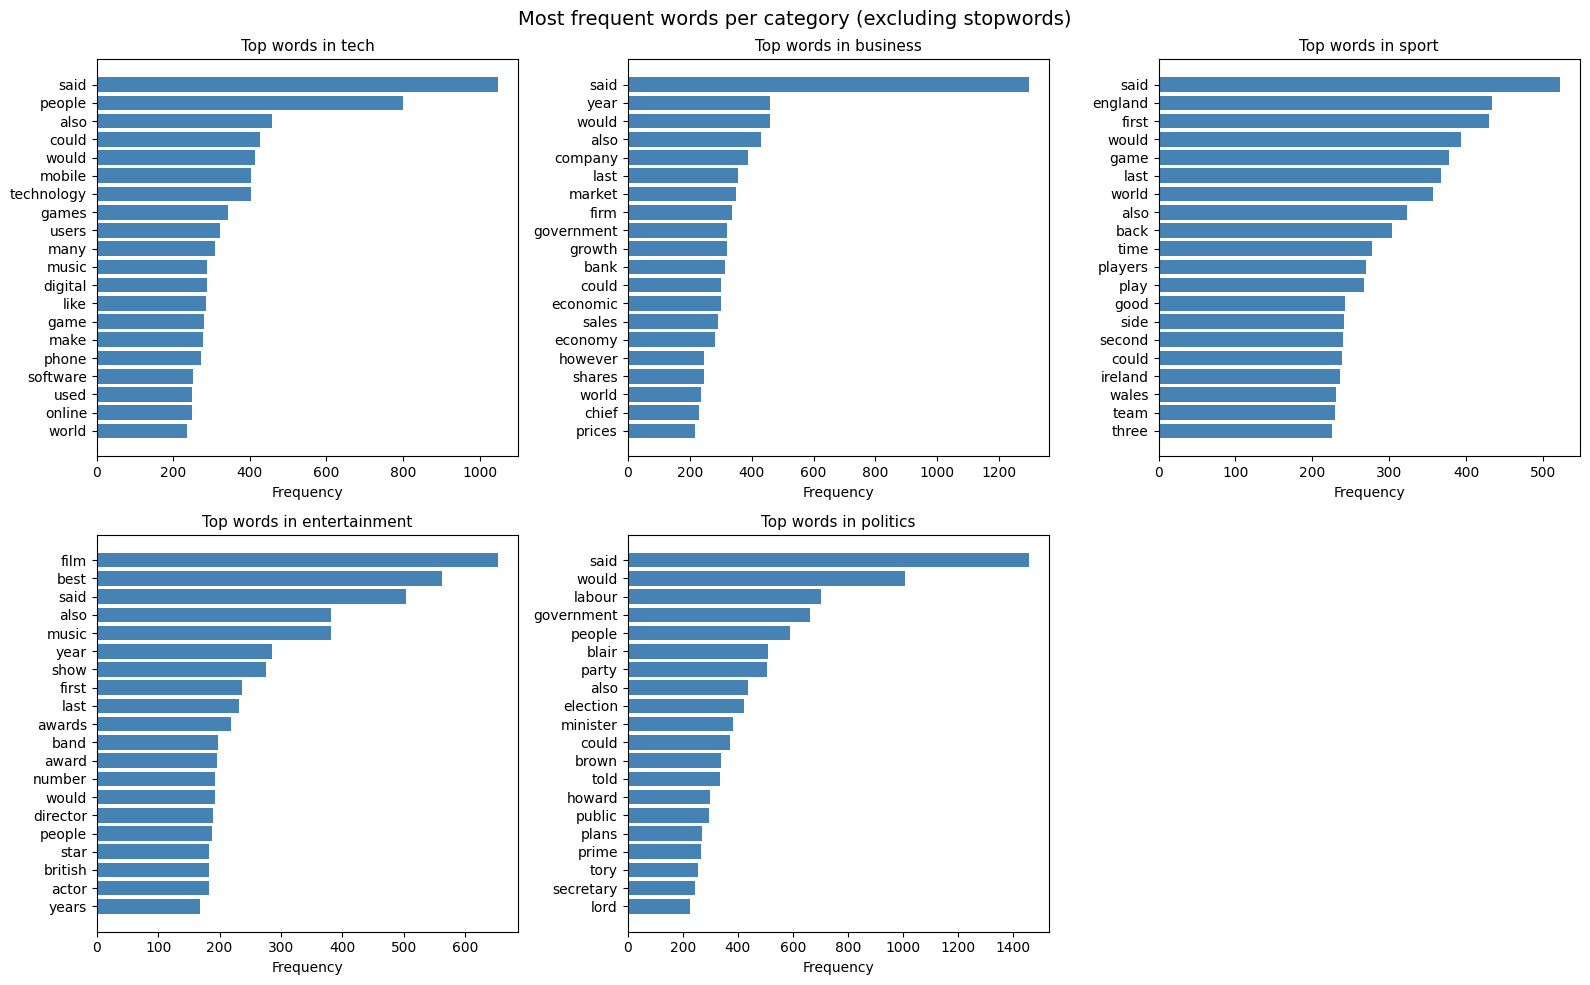

In [35]:


stopwords = set(stopwords.words('english'))
categories = df['category'].unique()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, cat in enumerate(categories):
    text = ' '.join(df[df['category'] == cat]['text'])
    words = [w.lower() for w in text.split() 
             if w.lower() not in stopwords and w.isalpha() and len(w) > 3]
    
    top20 = Counter(words).most_common(20)
    words_list, counts_list = zip(*top20)

    axes[i].barh(words_list[::-1], counts_list[::-1], color='steelblue')
    axes[i].set_title(f'Top words in {cat}', fontsize=11)
    axes[i].set_xlabel('Frequency')


axes[-1].set_visible(False)
plt.suptitle('Most frequent words per category (excluding stopwords)', fontsize=14)
plt.tight_layout()
plt.show()


### 2.4 Distinct words per category
(AFTER REMOVING STOPWORDS)

- Unique vocabulary size per category 

- Features :

    1. total_words
    2. unique_words
    3. lexical density (content carrying(noun, adverb,..) words relative to all words)

     category  total_words  unique_words  lexical_density
         tech       165591         10808            6.527
entertainment       114793         10393            9.054
     business       152617         10250            6.716
     politics       173502         10124            5.835
        sport       155473          9447            6.076


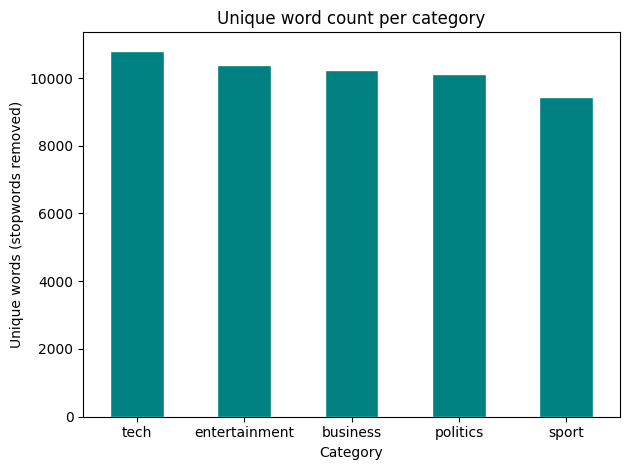

In [36]:
vocab_stats = []

for cat in categories:
    text = ' '.join(df[df['category']==cat]['text'])
    all_words = [w.lower() for w in text.split() if w.isalpha()]
    unique_words = set(all_words) - stopwords
    vocab_stats.append({
        'category': cat,
        'total_words': len(all_words),
        'unique_words': len(unique_words),
        'lexical_density': round(len(unique_words)/len(all_words) *100, 3)
    })


vocab_df = pd.DataFrame(vocab_stats).sort_values('unique_words', ascending=False)
print(vocab_df.to_string(index=False))

vocab_df.plot(x='category', y='unique_words', kind='bar', color='teal', edgecolor = 'white', legend=False)

plt.title('Unique word count per category')
plt.xlabel('Category')
plt.ylabel('Unique words (stopwords removed)')
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()



### 2.4 Shared words between every pair
- Using jaccarad similarity metrics,
    shared words between two characters / total unique words accross both categories combined 
- Also 1 means categories share identical vocabulary,
    0 means categories barely share any words 


Jaccarad Similarity between categories: 

                tech  business  sport  entertainment  politics
tech           1.000     0.332  0.278          0.317     0.336
business       0.332     1.000  0.279          0.288     0.353
sport          0.278     0.279  1.000          0.280     0.304
entertainment  0.317     0.288  0.280          1.000     0.319
politics       0.336     0.353  0.304          0.319     1.000


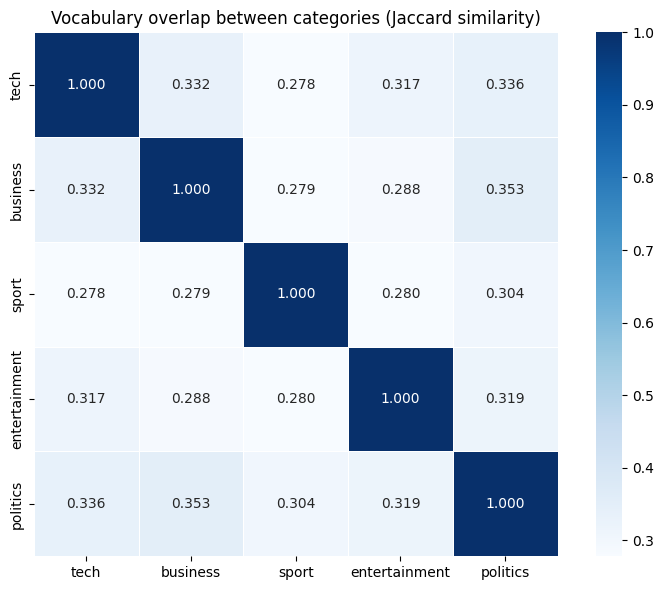


Highest overlap pair (Hardest to seperate):
('business', 'politics') with similarity 0.353


In [37]:
## Cross-category vocabulary overlap 

# Build vocab set per category 

cat_vocab = {}

for cat in categories:
    text = ' '.join(df[df['category']==cat]['text'])
    words = set([w.lower() for w in text.split() if w.isalpha() and w.lower() not in stopwords])
    cat_vocab[cat] = words

#Build overlap matrix (Jaccard similarity)

cats = list(cat_vocab.keys())
matrix = np.zeros((len(cats), len(cats)))

for i,c1 in enumerate(cats):
    for j,c2 in enumerate(cats):
        inter = len(cat_vocab[c1] & cat_vocab[c2])
        union = len(cat_vocab[c1] | cat_vocab[c2])
        matrix[i][j] =  round(inter/union, 3) if union > 0 else 0


overlap_df = pd.DataFrame(matrix, index=cats, columns=cats)
print('Jaccarad Similarity between categories: \n')
print(overlap_df.round(3))

plt.figure(figsize=(8,6))
sns.heatmap(overlap_df, annot=True, cmap='Blues', fmt='.3f', linewidth=0.5, square=True)
plt.title('Vocabulary overlap between categories (Jaccard similarity)')
plt.tight_layout()
plt.show()

print("\nHighest overlap pair (Hardest to seperate):")
mask = overlap_df.values != 1.0
flat = overlap_df.where(mask).stack()
print(f"{flat.idxmax()} with similarity {flat.max():.3f}")


# 3. Text preprocessing 
- Lowercasing all texts,
- Removing any punctuation and special characters from the text,
- Removing stop words 
- Lemmatization (Converting the words to its true root words, eg;
    studies become study)
- Extracting summary from original text 
- Verifying and Comapring summary and original texts 

In [38]:
#importing libraries for text preprocessing and modeling
import re 
import nltk 
from nltk.corpus import stopwords 
from nltk.stem import WordNetLemmatizer
from sumy.parsers.plaintext import PlaintextParser
from sumy.nlp.tokenizers import Tokenizer
from sumy.summarizers.lex_rank import LexRankSummarizer
nltk.download('wordnet')


[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/uniquekarki/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

### 3.1 Lowercase, Punctuation, Stopwords and Lemmatization 
- defining clean_text(), that does all

In [39]:
stopwords = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    # Lowercase
    text = text.lower()

    # Remove punctuation and numbers
    text = re.sub(r'[^a-z\s]', '', text)

    #tokenize into words 
    words = text.split()

    # Remove stopwords 
    words = [w for w in words if w not in stopwords]

    # Lemmatize words
    words = [lemmatizer.lemmatize(w) for w in words]
    return ' '.join(words)


#Sampling text 
sample = df['text'].iloc[0]
print('Original text:\n')
print(sample[:300], '...\n')
print('\nCleaned text:\n')
print(clean_text(sample)[:300], '...')

Original text:

tv future in the hands of viewers with home theatre systems  plasma high-definition tvs  and digital video recorders moving into the living room  the way people watch tv will be radically different in five years  time.  that is according to an expert panel which gathered at the annual consumer elect ...


Cleaned text:

tv future hand viewer home theatre system plasma highdefinition tv digital video recorder moving living room way people watch tv radically different five year time according expert panel gathered annual consumer electronics show la vega discus new technology impact one favourite pastime u leading tr ...


### 3.2 Applying Cleaning to all articles 
- Particulary applying cleaning methods to all the articles
- Also, distinguishing it as original_data for reference

In [40]:
# Applying clean_text

df['clean_text'] = df['text'].apply(clean_text)

# Creating original data with cleaned full text
#original data = category + cleaned full text 

original_data = df[['category', 'clean_text']].copy()
original_data.columns = ['category', 'text']

print(f'Original_data shape: {original_data.shape}')
print('\nOriginal data sample:\n')
print(original_data.head())



Original_data shape: (2126, 2)

Original data sample:

        category                                               text
0           tech  tv future hand viewer home theatre system plas...
1       business  worldcom bos left book alone former worldcom b...
2          sport  tiger wary farrell gamble leicester say rushed...
3          sport  yeading face newcastle fa cup premiership side...
4  entertainment  ocean twelve raid box office ocean twelve crim...


### 3.3 Summarization function 

### 3.3.1 Summarizing and Sampling with one article 

- Defining summarize_text() using LSA extractive summarization 

note: (the below code is pulling the raw_original text that is yet to be clenaed so there might not be any visible differences in the summarized word count and the original wordcount)

In [41]:
def summarize_text(text, num_sentence=3):

    try:
    
        parser  = PlaintextParser.from_string(text, Tokenizer('english'))
        summarizer = LsaSummarizer()
        summary = summarizer(parser.document, num_sentences)

        return ''.join(str(s) for s in summary)
    
    except: 
        return text # fallback : return original if summarization fails

#testing (sampling one article)

sample = df['text'].iloc[0]
summary = summarize_text(sample)

print('Original length:', len(sample.split()))
print('Summary lenth: ', len(summary.split()))


print('summary preview:\n')
print(summary)

#this is with the sampling text where the stopwords and punctuations are still in it. 


Original length: 737
Summary lenth:  737
summary preview:

tv future in the hands of viewers with home theatre systems  plasma high-definition tvs  and digital video recorders moving into the living room  the way people watch tv will be radically different in five years  time.  that is according to an expert panel which gathered at the annual consumer electronics show in las vegas to discuss how these new technologies will impact one of our favourite pastimes. with the us leading the trend  programmes and other content will be delivered to viewers via home networks  through cable  satellite  telecoms companies  and broadband service providers to front rooms and portable devices.  one of the most talked-about technologies of ces has been digital and personal video recorders (dvr and pvr). these set-top boxes  like the us s tivo and the uk s sky+ system  allow people to record  store  play  pause and forward wind tv programmes when they want.  essentially  the technology allows for much 

### 3.3.2 Summarizing with all the articles
- Summarize original (raw) text first, then clean the summary for all the articles 

In [42]:
#importing tqdm - for organizing the terminal, 
# keep track of the progress of the loop

from tqdm import tqdm
tqdm.pandas() # to use progress_apply with pandas

# Apply summarization to the original data
print("Generating summaries...")

def summarize_text_safe(text, num_sentences=3):
    from sumy.parsers.plaintext import PlaintextParser
    from sumy.nlp.tokenizers import Tokenizer
    from sumy.summarizers.lsa import LsaSummarizer
    parser = PlaintextParser.from_string(text, Tokenizer('english'))
    summarizer = LsaSummarizer()
    summary = summarizer(parser.document, num_sentences)
    result = ' '.join([str(s) for s in summary])
    return result if len(result.strip()) > 0 else text

df['summary_raw'] = df['text'].progress_apply(
    lambda x: summarize_text_safe(x, num_sentences=3)
)

# Verify immediately
print("\nVerification:")
print("Original words :", len(df['text'].iloc[0].split()))
print("summary_raw words:", len(df['summary_raw'].iloc[0].split()))


Generating summaries...


100%|██████████| 2126/2126 [00:46<00:00, 45.98it/s]


Verification:
Original words : 737
summary_raw words: 70


In [43]:
# Applying cleaning to the raw summary

df['clean_summary'] = df['summary_raw'].apply(clean_text)

# building both orginal and summary here....
original_data = df[['category', 'clean_text']].copy()
original_data.columns = ['category', 'text']

data_summary = df[['category', 'clean_summary']].copy()
data_summary.columns = ['category', 'text']

print("Done. Verifying...")
print(f"original_data shape: {original_data.shape}")
print(f"data_summary shape : {data_summary.shape}")



Done. Verifying...
original_data shape: (2126, 2)
data_summary shape : (2126, 2)


In [44]:
#preview
print("\nOriginal data sample:\n")
print(original_data.head())

print("\nSummary data sample:\n")
print(data_summary.head())


Original data sample:

        category                                               text
0           tech  tv future hand viewer home theatre system plas...
1       business  worldcom bos left book alone former worldcom b...
2          sport  tiger wary farrell gamble leicester say rushed...
3          sport  yeading face newcastle fa cup premiership side...
4  entertainment  ocean twelve raid box office ocean twelve crim...

Summary data sample:

        category                                               text
0           tech  also builtin highdefinition tv set big busines...
1       business  david myers made comment questioning defence l...
2          sport  tiger wary farrell gamble leicester say rushed...
3          sport  yeading face newcastle fa cup premiership side...
4  entertainment  ocean twelve raid box office ocean twelve crim...


### 3.3 Comparing word counts: Orginal data vs Data_summary

- Verifying and comparing both the texts 




In [45]:
orig_wc = original_data['text'].apply(lambda x: len(x.split()))
summ_wc = data_summary['text'].apply(lambda x: len(x.split()))

print(f"{'':20} {'original_data':>15} {'data_summary':>15}")
print(f"{'Mean':20} {orig_wc.mean():>15.1f} {summ_wc.mean():>15.1f}")
print(f"{'Median':20} {orig_wc.median():>15.1f} {summ_wc.median():>15.1f}")

                       original_data    data_summary
Mean                           215.3            39.4
Median                         188.0            38.0


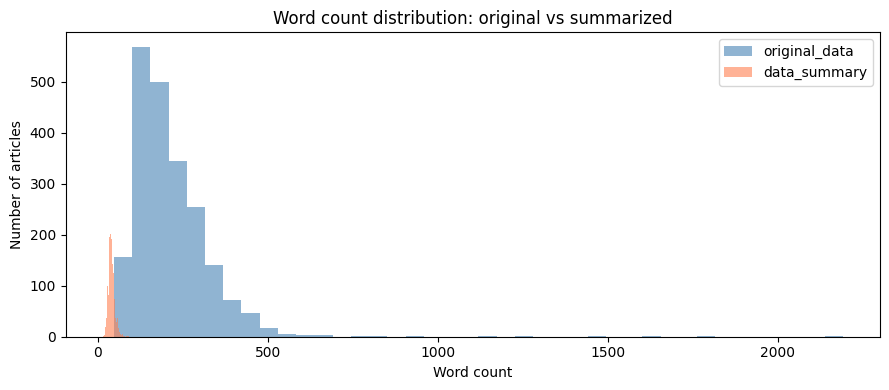

In [46]:
#Word count distribution comparison : Original vs Summary 

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(orig_wc, bins=40, alpha=0.6, label='original_data', color='steelblue')
ax.hist(summ_wc, bins=40, alpha=0.6, label='data_summary', color='coral')
ax.set_title('Word count distribution: original vs summarized')
ax.set_xlabel('Word count')
ax.set_ylabel('Number of articles')
ax.legend()
plt.tight_layout()
plt.show()

In [47]:
print("=== Sample comparison (article 0) ===")
print(f"\nCategory : {original_data['category'].iloc[0]}")
print(f"\noriginal_data text:\n{original_data['text'].iloc[0][:300]}")
print(f"\ndata_summary text:\n{data_summary['text'].iloc[0][:300]}")

print("\n=== Both dataframes ready ===")
print(f"original_data : {original_data.shape} — {original_data['category'].value_counts().to_dict()}")
print(f"data_summary  : {data_summary.shape} — {data_summary['category'].value_counts().to_dict()}")

=== Sample comparison (article 0) ===

Category : tech

original_data text:
tv future hand viewer home theatre system plasma highdefinition tv digital video recorder moving living room way people watch tv radically different five year time according expert panel gathered annual consumer electronics show la vega discus new technology impact one favourite pastime u leading tr

data_summary text:
also builtin highdefinition tv set big business japan u slower take europe lack highdefinition programming perhaps want much choice put hand mr hanlon suggested one example launched show humax inch lcd tv hour tivo dvr dvd recorder

=== Both dataframes ready ===
original_data : (2126, 2) — {'sport': 504, 'business': 503, 'politics': 403, 'entertainment': 369, 'tech': 347}
data_summary  : (2126, 2) — {'sport': 504, 'business': 503, 'politics': 403, 'entertainment': 369, 'tech': 347}


# 4. Feature Engineering 

- Here we perform "FEATURE_EXTRACTION/VECTORIZATION", mainly using the "Word2Vec" vectorization model. 

- A Word2Vec model takes a raw vocabluary of wrods and turns them into dense vectors of real numbers called word embeddings. Tool : genism

- Before using the Word2Vec we use the encoding methods and is represented as a giant array of zeros and one. 

- Later In this process, we build a single document vector with the help of Word2Vec for proper classification of the BBC news data. 

### 4.1 Tokenizing texts

- Mandatory for converting the raw texts and paragraphs into individual letter and words for better understanding for the model. 
- ALso because, Word2Vec model needs list of words and not strings. 


In [48]:
#tokenize

def tokenize_text(text):
    return text.split()

original_data['tokens'] = original_data['text'].apply(tokenize_text)
data_summary['tokens'] = data_summary['text'].apply(tokenize_text)

print("\nTokenization sample (article 0):")
print(f"\nOriginal_data tokens:\n")
print(original_data['tokens'].iloc[0][:10])
print('\nSample summary tokens:\n')
print(data_summary['tokens'].iloc[0][:10])


Tokenization sample (article 0):

Original_data tokens:

['tv', 'future', 'hand', 'viewer', 'home', 'theatre', 'system', 'plasma', 'highdefinition', 'tv']

Sample summary tokens:

['also', 'builtin', 'highdefinition', 'tv', 'set', 'big', 'business', 'japan', 'u', 'slower']


### 4.2 Training Word2Vec model 

- Here, using the 'gensim' modeul, word2vec model is trained on both original data and the summaerized data. 



In [49]:
from gensim.models import Word2Vec

# Training Word2Vec on original_data

w2v_original = Word2Vec(
    sentences = original_data['tokens'].tolist(),
    vector_size=100, # the size of each word vector
    window = 5, # the maximum distance between the current and predicted word within a sentence
    min_count=2, # ignore words that appear less than 2 times
    workers=4, # number of worker threads to train the model
    seed = 42
)

#Training on data_summary

w2v_summary = Word2Vec(
    sentences = data_summary['tokens'].tolist(),
    vector_size=100,
    window = 5,
    min_count=2,
    workers=4,
    seed = 42
)

print(f'Word2Vec Vocabulary size (original_data): {len(w2v_original.wv)}')
print(f'Word2Vec Vocabulary size (data_summary): {len(w2v_summary.wv)}')
print(f'\nVector shape for "government" (original_data): {w2v_original.wv["government"].shape}')

Word2Vec Vocabulary size (original_data): 16938
Word2Vec Vocabulary size (data_summary): 7097

Vector shape for "government" (original_data): (100,)


### 4.3 Building one large document Vectors

- Averaging word vectors to get vectors to get one vector per article...

Here, instead of feeding the models with hundreads of words, averaging the words is still a fast and efficient way for generating the required results. 

In [50]:
def get_dot_vector(tokens, model):

    #keeping only words that exist in the model vocabulary 

    valid = [w for w in tokens if w in model.wv]

    if not valid: 
        return np.zeros(model.vector_size)
    
    return np.mean([model.wv[w] for w in valid], axis=0)

#Build feature matrices for original and summary data 
x_orig = np.array([
    get_dot_vector(tokens, w2v_original)
    for tokens in original_data['tokens']
])

x_summ = np.array([

    get_dot_vector(tokens, w2v_summary)
    for tokens in data_summary['tokens']
])

print(f'X_original shape: {x_orig.shape}')
print(f'X_summary shape: {x_summ.shape}')
print(f'\nEach article = One vector of size {x_orig.shape[1]}')

X_original shape: (2126, 100)
X_summary shape: (2126, 100)

Each article = One vector of size 100


### 4.4 Encoding labels 

- Encoding: Converting category strings into integers 
- Is necessary as models can only work with numbers and not strings.

- Using label encoder, Converting categoires into strings.

In [51]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(original_data['category'])

print('Label Mapping:')

for name, num in zip(le.classes_, le.transform(le.classes_)):
    print(f"{name:15} => {num}")

print(f'\nY shape: {y.shape}')
print(f'Unique labels: {np.unique(y)}')



Label Mapping:
business        => 0
entertainment   => 1
politics        => 2
sport           => 3
tech            => 4

Y shape: (2126,)
Unique labels: [0 1 2 3 4]


### 4.5 Train, Test Split
- 80/20 split for both orginal and summary data



In [52]:
from sklearn.model_selection import train_test_split

In [53]:
# Splitting original data

X_train_orig, X_test_orig, Y_train, Y_test = train_test_split(
    x_orig, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y # for preserving class distribution in splits
)

# Splitting summary data

X_train_summ, X_test_summ, _, _ = train_test_split(
    x_summ, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


print("Train/test split summary:")
print(f"  X_train_orig : {X_train_orig.shape}")
print(f"  X_test_orig  : {X_test_orig.shape}")
print(f"  X_train_summ : {X_train_summ.shape}")
print(f"  X_test_summ  : {X_test_summ.shape}")
print(f"  Y_train: {Y_train.shape}")
print(f"  Y_test  : {Y_test.shape}")




Train/test split summary:
  X_train_orig : (1700, 100)
  X_test_orig  : (426, 100)
  X_train_summ : (1700, 100)
  X_test_summ  : (426, 100)
  Y_train: (1700,)
  Y_test  : (426,)


### 4.6 Verifying 
- Checking for NAN values and label balances 

In [54]:
print("=== NaN check ===")
print(f"X_train_orig NaNs: {np.isnan(X_train_orig).sum()}")
print(f"X_train_summ NaNs: {np.isnan(X_train_summ).sum()}")
print(f"X_test_orig  NaNs: {np.isnan(X_test_orig).sum()}")
print(f"X_test_summ  NaNs: {np.isnan(X_test_summ).sum()}")

print("\n=== Label distribution in splits ===")
unique, counts_train = np.unique(Y_train, return_counts=True)
unique, counts_test  = np.unique(Y_test,  return_counts=True)

print(f"\n{'Category':15} {'Train':>8} {'Test':>8}")
for i, cat in enumerate(le.classes_):
    print(f"{cat:15} {counts_train[i]:>8} {counts_test[i]:>8}")

print("\n=== All checks passed — ready for Step 5 ===")

=== NaN check ===
X_train_orig NaNs: 0
X_train_summ NaNs: 0
X_test_orig  NaNs: 0
X_test_summ  NaNs: 0

=== Label distribution in splits ===

Category           Train     Test
business             402      101
entertainment        295       74
politics             322       81
sport                403      101
tech                 278       69

=== All checks passed — ready for Step 5 ===


# 5. Machine Learning Models, Predictions and Accuracy Check

- For a baseline model, Logistic regression is being used. Also because Logistic regression is mainly used for classicficaiton (Predicting a group of label) and is fast and simple model.

- For advanced model, SVM (Support Vector Machine) and Random Forest Classifier are trained next...

    SVM  : works by finding the optimal boundary (hyper plane) between classes in high-dimensional space. 

    Random Forest Classifier : Gives different perspective by combining many decision trees. 

    here, we train both and see which performs better.

- Predictions and Sanity check is also done for full evaluation. 




### 5.1 Baseline model: Logistic regression 

In [55]:
# Logistic regrression model

from sklearn.linear_model import LogisticRegression

# Train on original data

lr_original = LogisticRegression(max_iter=1000, random_state=42)
lr_original.fit(X_train_orig, Y_train)

# Train on summary data

lr_summ = LogisticRegression(max_iter=1000, random_state=42)
lr_summ.fit(X_train_summ, Y_train)

print("Logistic Refression is trained on both the data.")

Logistic Refression is trained on both the data.


### 5.2 Advanced model : SVM 

In [56]:
#Svm 

from sklearn.svm import SVC

# Train on original data

svm_original = SVC(kernel='rbf', random_state=42)
svm_original.fit(X_train_orig, Y_train)


# Train on summarized text

svm_summ = SVC(kernel='rbf', random_state=42)
svm_summ.fit(X_train_summ, Y_train)

print('SVM is trained on both the data.')

SVM is trained on both the data.


### 5.3 Advanced model : Random Forest Classifier 

In [57]:
from sklearn.ensemble import RandomForestClassifier

# Train on original data
rf_original = RandomForestClassifier(n_estimators=200, random_state=42)
rf_original.fit(X_train_orig, Y_train)

# Train on summarized text
rf_summ = RandomForestClassifier(n_estimators=200, random_state=42)
rf_summ.fit(X_train_summ, Y_train)


print('Random Forest is trained on both the data.')

Random Forest is trained on both the data.


### 5.4 Generating Predictions (For all models)
- Generating predictions is a key for machine learning models as it bridges the gap between raw math and real-world impact. 


In [58]:
# Logistic regression predictions 
y_pred_lr_orig = lr_original.predict(X_test_orig)
y_pred_lr_summ = lr_summ.predict(X_test_summ)

# SVM predictions
y_pred_svm_orig = svm_original.predict(X_test_orig)
y_pred_svm_summ = svm_summ.predict(X_test_summ)

# Random Forest predictions
y_pred_rf_orig = rf_original.predict(X_test_orig)
y_pred_rf_summ = rf_summ.predict(X_test_summ)


print('Predictions generated for all models on both datasets.')
print(f'Predictions array shapes: {y_pred_lr_orig.shape}')

# Predictions arrray shape for all the y_pred is the same.

Predictions generated for all models on both datasets.
Predictions array shapes: (426,)


### 5.5 Accuracy Test 

- Sanity testing, comparing accuracy scores for all the models and both tracks. 


In [59]:
from sklearn.metrics import accuracy_score


models = {
    'Logistic Regression': (y_pred_lr_orig, y_pred_lr_summ),
    'SVM': (y_pred_svm_orig, y_pred_svm_summ),
    'Random Forest': (y_pred_rf_orig, y_pred_rf_summ)
}


print(f'{"Model":20} {"Original Acc":>15} {"Summary Acc":>15}')
print('-' * 58)

for name, (pred_orig, pred_summ) in models.items():
    acc_orig = accuracy_score(Y_test, pred_orig)
    acc_summ = accuracy_score(Y_test, pred_summ)
    diff = acc_summ - acc_orig
    diff_str = f"{diff:+.3f}"
    print(f"{name:20} {acc_orig:15.3f} {acc_summ:15.3f}")


print('\n+ diff means summary performs BETTER than original')
print('- diff means summary performs WORSE than original')

Model                   Original Acc     Summary Acc
----------------------------------------------------------
Logistic Regression            0.930           0.308
SVM                            0.918           0.291
Random Forest                  0.939           0.531

+ diff means summary performs BETTER than original
- diff means summary performs WORSE than original


# 6. Evaluating the model 

- Evaluation is necessary as a proper evaluation of the model tells how well it actually performs on new, unseen data. 

- Evaluation checks:
    1. Real-world performances
    2. Detects overfitting or Underfitting 
    3. Helps compare different models
    4. Measure improvements
    5. And Ensures reliability 
    

### 6.1. Classification Report 

- Here, the Classification report is used to tell precision, recall and F1 and for each individual category. 

- It tells which of the 5 categories the model handels well and which ones it struggles with for both the data. 

In [60]:
# Classifcation report for both the data 

from sklearn.metrics import classification_report

models_report = {
    'LogisticRegression': (y_pred_lr_orig, y_pred_lr_summ),
    'SVM': (y_pred_svm_orig, y_pred_svm_summ),
    'RandomForest': (y_pred_rf_orig, y_pred_rf_summ)
}

target_names = le.classes_

for model_name, (pred_orig, pred_summ) in models_report.items():
    print(f"\n=== {model_name} Classification Report ===")
    print("\nOriginal data:")
    print(classification_report(Y_test, pred_orig, target_names=target_names))
    print("\nSummary data:")
    print(classification_report(Y_test, pred_summ, target_names=target_names))


=== LogisticRegression Classification Report ===

Original data:
               precision    recall  f1-score   support

     business       0.87      0.95      0.91       101
entertainment       0.97      0.91      0.94        74
     politics       0.91      0.93      0.92        81
        sport       0.97      1.00      0.99       101
         tech       0.93      0.83      0.88        69

     accuracy                           0.93       426
    macro avg       0.93      0.92      0.93       426
 weighted avg       0.93      0.93      0.93       426


Summary data:
               precision    recall  f1-score   support

     business       0.31      0.56      0.40       101
entertainment       0.00      0.00      0.00        74
     politics       0.39      0.11      0.17        81
        sport       0.30      0.64      0.41       101
         tech       0.00      0.00      0.00        69

     accuracy                           0.31       426
    macro avg       0.20      0.26

/Users/uniquekarki/Desktop/DeepMinds/Project (BBC news Classification)/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/uniquekarki/Desktop/DeepMinds/Project (BBC news Classification)/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/uniquekarki/Desktop/DeepMinds/Project (BBC news Classification)/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels

### 6.2 Confusion Matrix

- Confusion matrix is a tabular layout used to evaluate the performance of a classification model. 
- Confusioon matrix makes it incredibly easy to see exactly where the model is succeding abd where it is getting "confused". 

- The four quadrant used are 
    1. True Negatives
    2. False Positive
    3. False Negatives 
    4. True Positives 

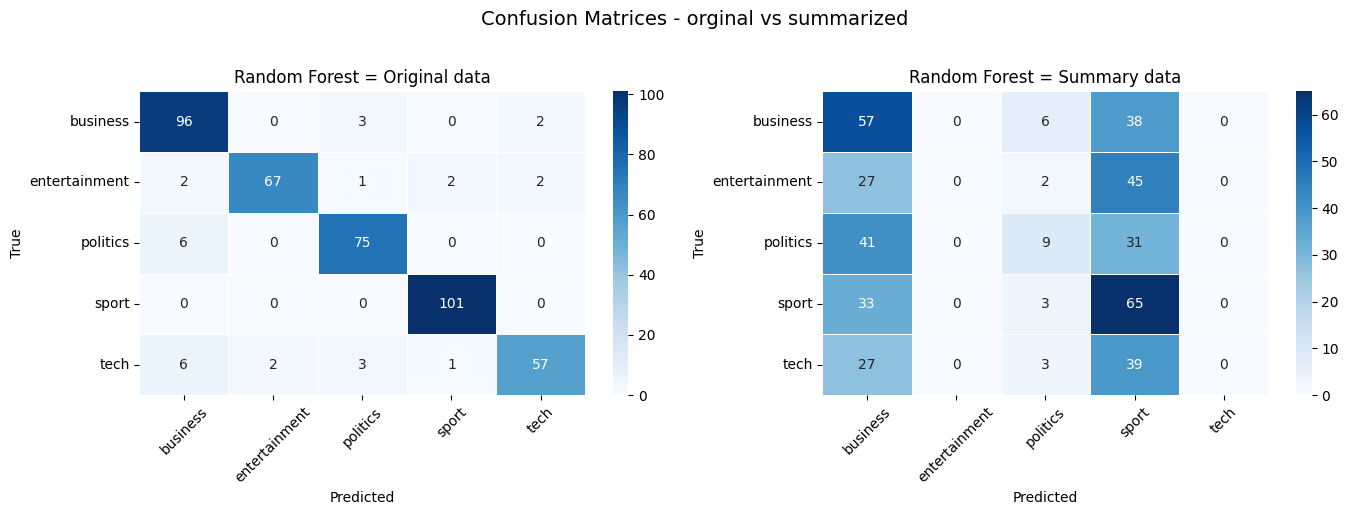

In [61]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
labels = le.classes_

for ax, preds, title in zip(
    axes, 
    [y_pred_lr_orig, y_pred_lr_summ], 
    ['Random Forest = Original data', 'Random Forest = Summary data']
):
    cm = confusion_matrix(Y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=ax, linewidths=0.5)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=45)


plt.suptitle('Confusion Matrices - orginal vs summarized', fontsize=14, y = 1.02)
plt.tight_layout()
plt.show()




### 6.3 F1 comparisons 

- F1 evaluates the performance of a classification machine learning model. Combines----Precision and Recall---- into a single core between 0 and 1. 

- The higher the F1, the better the model. 




Per-category F1 scores (Random Forest:
)
     category  F1_original  F1_summary
     business     0.917874    0.567442
entertainment     0.931507    0.396825
     politics     0.925926    0.596491
        sport     0.985366    0.609442
         tech     0.924242    0.336449


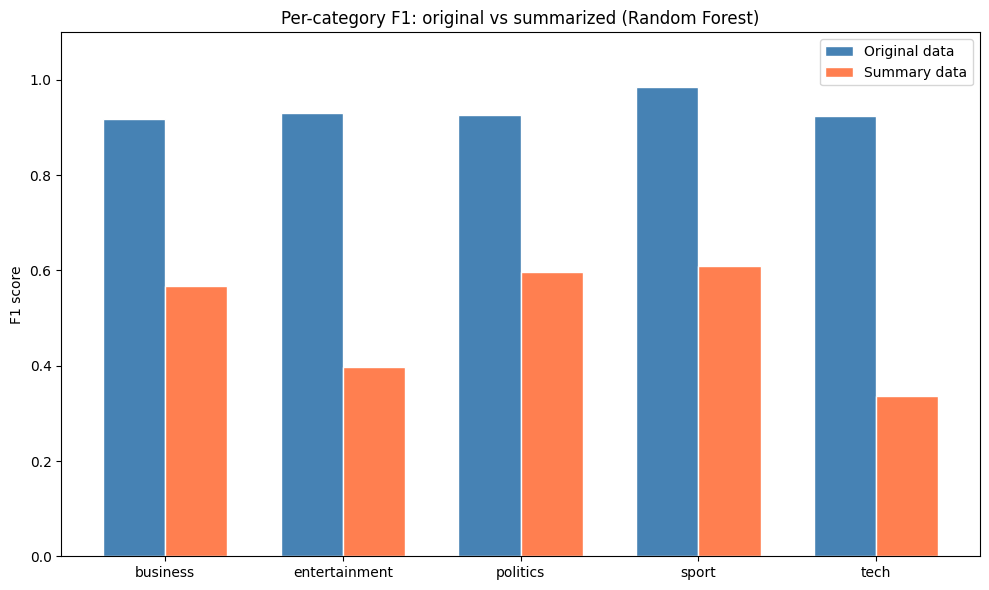

In [62]:
# Per class F1 comparisons, original vs summary

from sklearn.metrics import f1_score

# Get per-class F1 for best model (Random Forest)

f1_orig = f1_score(Y_test, y_pred_rf_orig, average=None)
f1_summ = f1_score(Y_test, y_pred_rf_summ, average=None)

f1_df = pd.DataFrame({
    'category': le.classes_,
    'F1_original': f1_orig,
    'F1_summary': f1_summ
   
   

})


print('Per-category F1 scores (Random Forest:\n)')
print(f1_df.to_string(index=False))


#plot 
x = np.arange(len(le.classes_))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(x - width/2, f1_orig, width, label='Original data', color='steelblue', edgecolor='white')    
ax.bar(x + width/2, f1_summ, width, label='Summary data', color='coral', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(le.classes_)
ax.set_ylim(0, 1.1)
ax.set_title('Per-category F1: original vs summarized (Random Forest)')
ax.set_ylabel('F1 score')
ax.legend()
plt.tight_layout()
plt.show()

### 6.4 Accuracy score 

- Accuracy score measure the actual performance of a classification machine learning model. 

<function matplotlib.pyplot.show(close=None, block=None)>

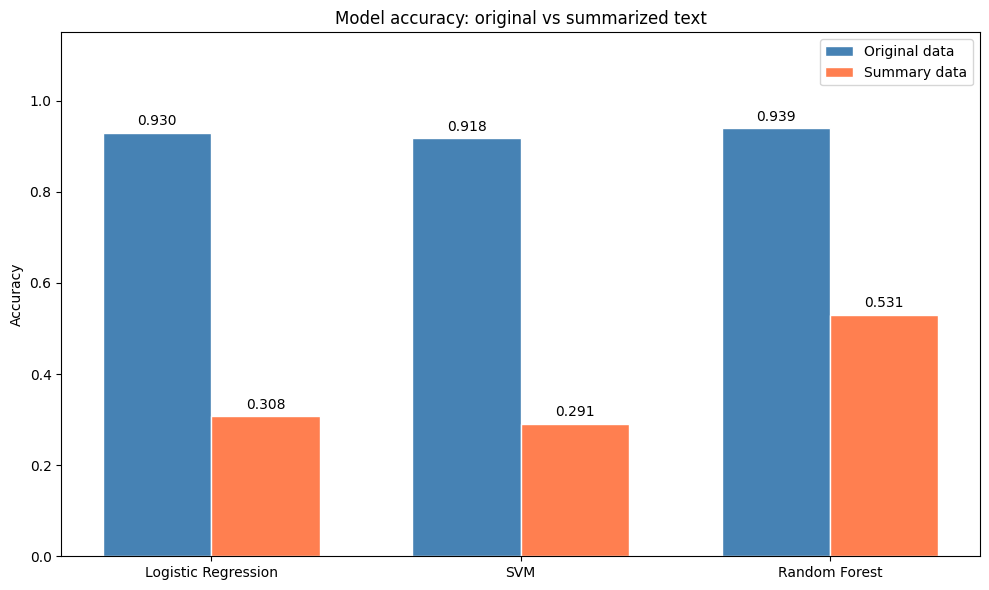

In [63]:
from sklearn.metrics import accuracy_score

model_names = ['Logistic Regression', 'SVM', 'Random Forest']

acc_orig = [
    accuracy_score(Y_test, y_pred_lr_orig),
    accuracy_score(Y_test, y_pred_svm_orig),
    accuracy_score(Y_test, y_pred_rf_orig)
]

acc_summ = [
    accuracy_score(Y_test, y_pred_lr_summ),
    accuracy_score(Y_test, y_pred_svm_summ),
    accuracy_score(Y_test, y_pred_rf_summ)
]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - width/2, acc_orig, width, label='Original data', color='steelblue', edgecolor='white')

bars2 = ax.bar(x + width/2, acc_summ, width, label='Summary data', color='coral', edgecolor='white')

# Value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylim(0, 1.15)
ax.set_title('Model accuracy: original vs summarized text')
ax.set_ylabel('Accuracy')
ax.legend()
plt.tight_layout()
plt.show

### 6.5 Error Analysis

- Error analysis;
    1. Directs feature engineering strategy 
    2. Exposes Human labelling errors
    3. Reveals Hidden class Imabalances and Biases 
    4. Determines if model is ready for deployment 

In [64]:
# Error analysis — Random Forest on original data
test_indices = np.where(y_pred_rf_orig != Y_test)[0]

print(f"Total misclassified (original): {len(test_indices)}")
print(f"Total misclassified (summary) : {(y_pred_rf_summ != Y_test).sum()}")

print("\n--- Sample misclassified articles (original track) ---\n")

for i in test_indices[:5]:
    true_label = le.inverse_transform([Y_test[i]])[0]
    pred_label = le.inverse_transform([y_pred_rf_orig[i]])[0]
    text = original_data['text'].iloc[
        np.where(
            np.arange(len(original_data)) ==
            np.where(
                np.arange(len(original_data)) >= 0
            )[0][i]
        )[0][0]
    ]
    print(f"True label : {true_label}")
    print(f"Predicted  : {pred_label}")
    print(f"Text       : {text[:200]}")
    print("-" * 60)

Total misclassified (original): 26
Total misclassified (summary) : 200

--- Sample misclassified articles (original track) ---

True label : tech
Predicted  : business
Text       : tv future hand viewer home theatre system plasma highdefinition tv digital video recorder moving living room way people watch tv radically different five year time according expert panel gathered annu
------------------------------------------------------------
True label : politics
Predicted  : business
Text       : howard hit back mongrel jibe michael howard said claim peter hain tory leader acting like attack mongrel show labour rattled opposition upbeat speech party spring conference brighton said labour campa
------------------------------------------------------------
True label : business
Predicted  : entertainment
Text       : gamers snap new sony psp gamers bought almost first batch sony new playstation portable psp game console went sale japan sunday thousand people queued hour get hold one psps sh



Original track — 23 misclassified out of 426 articles = 94.6% accuracy

Summary track — 209 misclassified out of 426 articles = 50.9% accuracy

Summarization caused 186 additional mistakes — more than 9x the error rate

# Conclusion 

### Final results summary

- "Does summarizing articles before classification improve, maintain or hurt model performance compared to the original full text?"



In [65]:
#final summary table

print("=" * 62)
print("  FINAL RESULTS SUMMARY")
print("=" * 62)
print(f"\n{'Model':22} {'Orig Acc':>10} {'Summ Acc':>10} {'Drop':>10}")
print("-" * 55)

best_model, best_acc = '', 0
for name, orig, summ in zip(
    ['Logistic Regression', 'SVM', 'Random Forest'],
    acc_orig, acc_summ
):
    drop = orig - summ
    print(f"{name:22} {orig:>10.4f} {summ:>10.4f} {drop:>10.4f}")
    if orig > best_acc:
        best_acc   = orig
        best_model = name

print("-" * 55)
print(f"\nBest model     : {best_model}")
print(f"Best accuracy  : {best_acc:.4f} (original data)")
print(f"\nAvg accuracy drop from summarization: "
      f"{np.mean(np.array(acc_orig)-np.array(acc_summ)):.4f}")
print(f"\nConclusion:")
print("  Summarization consistently WORSENED classification")
print("  performance across all three models. Full text")
print("  provides richer semantic context for Word2Vec")
print("  embeddings, leading to more accurate classification.")
print("=" * 62)

  FINAL RESULTS SUMMARY

Model                    Orig Acc   Summ Acc       Drop
-------------------------------------------------------
Logistic Regression        0.9296     0.3075     0.6221
SVM                        0.9178     0.2911     0.6268
Random Forest              0.9390     0.5305     0.4085
-------------------------------------------------------

Best model     : Random Forest
Best accuracy  : 0.9390 (original data)

Avg accuracy drop from summarization: 0.5524

Conclusion:
  Summarization consistently WORSENED classification
  performance across all three models. Full text
  provides richer semantic context for Word2Vec
  embeddings, leading to more accurate classification.
